In [1]:
# train a linear regrssion model using Pseudo inverse of A

import numpy as np

A = [[170, 1],
     [155, 1],
     [150, 1],
     [175, 1],
     [165, 1]]

Y = [[65], [50], [45], [70], [55]]

In [2]:
At = np.transpose(A)

print(At)

[[170 155 150 175 165]
 [  1   1   1   1   1]]


In [3]:
AtA = np.dot(At,A)
AtY = np.dot(At,Y)

print(AtA)
print(AtY)

[[133275    815]
 [   815      5]]
[[46875]
 [  285]]


In [4]:
inv_AtA = np.linalg.inv(AtA)
X = np.dot(inv_AtA,AtY)

In [5]:
print(X)

[[   0.97674419]
 [-102.20930233]]


Linear regression weights: w = 0.9767441860464985 , b = -102.20930232557923
Linear regression MSE: 3.953488372093023
Residuals: [ 1.1627907   0.81395349  0.69767442  1.27906977 -3.95348837]


C:\Users\Admin\AppData\Local\Temp\ipykernel_25300\3913817785.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w, b = float(theta[0]), float(theta[1])


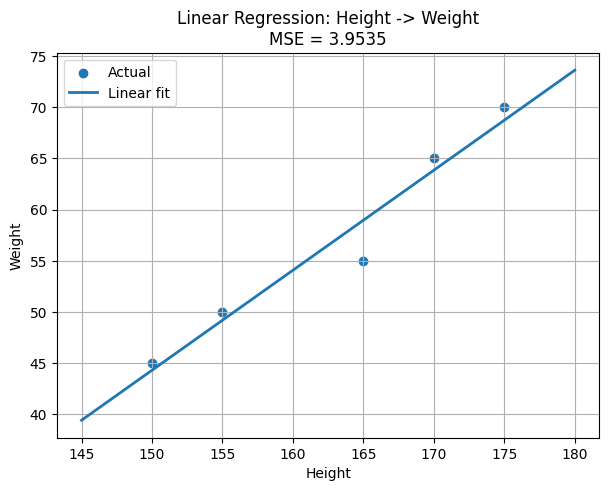

Trained logistic theta: [ 0.36396772 -0.23896175  0.00521322]
Final logistic loss: 0.0001940256223708919
Logistic accuracy: 1.0
Probabilities:
 [9.99386103e-01 2.76590733e-04 7.92554793e-05 9.99999879e-01
 9.99999961e-01]
Preds: [1 0 0 1 1] True: [1 0 0 1 1]


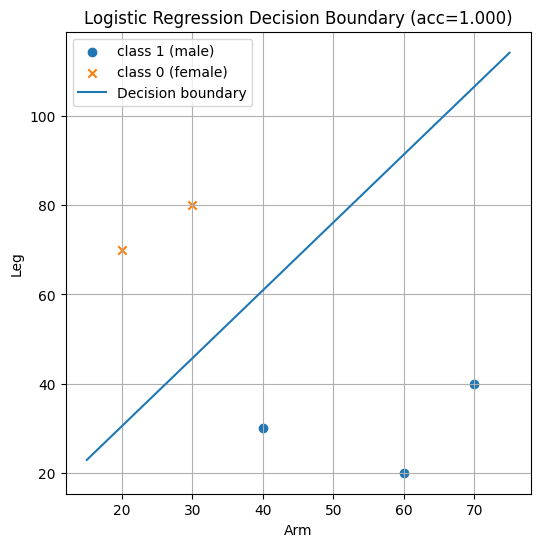

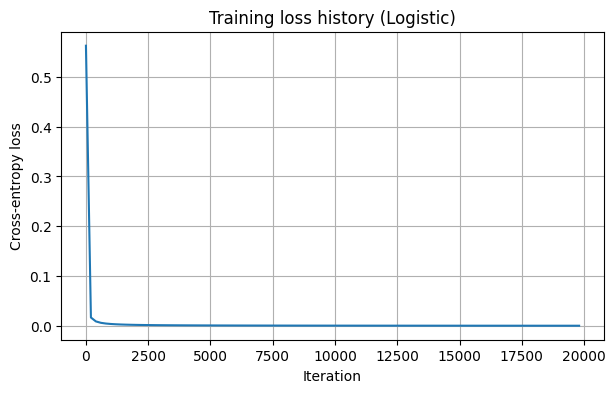

sklearn accuracy: 1.0
sklearn coef, intercept: [[ 0.12070748 -0.21548343]] [7.09755521]
Linear scores (from logistic weights): [ 7.39506964 -8.19269501 -9.44275475 15.92448382 17.06404157]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.linear_model import LogisticRegression  # chỉ để so sánh (tùy chọn)

# --------- PART 1: Linear Regression (pseudo-inverse) ----------
# Dataset (height -> weight) bạn cung cấp
A = np.array([[170, 1],
              [155, 1],
              [150, 1],
              [175, 1],
              [165, 1]], dtype=float)   # shape (5,2) (feature, bias)
Y = np.array([[65], [50], [45], [70], [55]], dtype=float)  # shape (5,1)

# compute theta = (A^T A)^(-1) A^T Y
At = A.T
AtA = At @ A
AtY = At @ Y
theta = np.linalg.inv(AtA) @ AtY   # shape (2,1)
w, b = float(theta[0]), float(theta[1])
print("Linear regression weights: w =", w, ", b =", b)

# predictions and residuals
Y_pred = A @ theta
mse = mean_squared_error(Y, Y_pred)
print("Linear regression MSE:", mse)
residuals = (Y - Y_pred).flatten()
print("Residuals:", residuals)

# plot data + fit line
plt.figure(figsize=(7,5))
xs = A[:,0]
plt.scatter(xs, Y.flatten(), marker='o', label='Actual')
x_line = np.linspace(min(xs)-5, max(xs)+5, 100)
y_line = w * x_line + b
plt.plot(x_line, y_line, label='Linear fit', linewidth=2)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Linear Regression: Height -> Weight\nMSE = {:.4f}'.format(mse))
plt.legend()
plt.grid(True)
plt.show()


# --------- PART 2: Logistic Regression (gradient descent, 2 features) ----------
# Use the arm/leg/gen dataset (gen labels were -1 or 1; convert to 0/1)
arm = np.array([40, 30, 20, 70, 60], dtype=float)
leg = np.array([30, 80, 70, 40, 20], dtype=float)
gen = np.array([1, -1, -1, 1, 1], dtype=int)   # -1/1

# Convert to 0/1 labels for logistic
Y_log = (gen == 1).astype(int).reshape(-1,1)   # 1 -> male(1), -1 -> female(0)
X_log = np.vstack([arm, leg]).T               # shape (5,2)
n, d = X_log.shape

# add bias column
Xb = np.hstack([X_log, np.ones((n,1))])  # shape (n,3)

# Sigmoid and loss
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def compute_loss(theta_vec):
    z = Xb @ theta_vec.reshape(-1,1)
    h = sigmoid(z)
    # binary cross-entropy
    eps = 1e-9
    loss = - np.mean(Y_log * np.log(h + eps) + (1 - Y_log) * np.log(1 - h + eps))
    return float(loss)

# Gradient descent training
theta = np.zeros((d+1,1))   # initial weights (w1,w2,bias)
alpha = 0.0008
iters = 20000
loss_history = []

for it in range(iters):
    z = Xb @ theta
    h = sigmoid(z)
    grad = (Xb.T @ (h - Y_log)) / n   # shape (d+1,1)
    theta -= alpha * grad
    if it % 200 == 0:
        loss_history.append(compute_loss(theta))

print("Trained logistic theta:", theta.flatten())
print("Final logistic loss:", compute_loss(theta))

# Predictions and accuracy
probs = sigmoid(Xb @ theta)
y_pred = (probs >= 0.5).astype(int)
acc = accuracy_score(Y_log, y_pred)
print("Logistic accuracy:", acc)
print("Probabilities:\n", probs.flatten())
print("Preds:", y_pred.flatten(), "True:", Y_log.flatten())

# Plot decision boundary & data
plt.figure(figsize=(6,6))
# scatter points
plt.scatter(X_log[Y_log.flatten()==1,0], X_log[Y_log.flatten()==1,1], marker='o', label='class 1 (male)')
plt.scatter(X_log[Y_log.flatten()==0,0], X_log[Y_log.flatten()==0,1], marker='x', label='class 0 (female)')

# decision boundary: theta0*x + theta1*y + theta2 = 0 -> y = -(theta0 x + theta2)/theta1
t0, t1, t2 = theta.flatten()
if abs(t1) > 1e-6:
    x_vals = np.linspace(min(arm)-5, max(arm)+5, 100)
    y_vals = - (t0 * x_vals + t2) / t1
    plt.plot(x_vals, y_vals, label='Decision boundary')
else:
    # vertical boundary
    x_line = -t2/t0
    plt.axvline(x_line, label='Decision boundary')

plt.xlabel('Arm')
plt.ylabel('Leg')
plt.legend()
plt.title(f'Logistic Regression Decision Boundary (acc={acc:.3f})')
plt.grid(True)
plt.show()

# Plot loss history
plt.figure(figsize=(7,4))
plt.plot(np.arange(0, it+1, 200), loss_history)
plt.xlabel('Iteration')
plt.ylabel('Cross-entropy loss')
plt.title('Training loss history (Logistic)')
plt.grid(True)
plt.show()


clf = LogisticRegression().fit(X_log, Y_log.ravel())
sk_pred = clf.predict(X_log)
print("sklearn accuracy:", accuracy_score(Y_log, sk_pred))
print("sklearn coef, intercept:", clf.coef_, clf.intercept_)


scores = Xb @ theta
print("Linear scores (from logistic weights):", scores.flatten())
